***

## DL & GEN AI - 21st July 2026

## PRACTICAL 2 : MLP Activation and Layer Experiments

***

## 1] classification problem

This practical uses the **handwritten digits dataset**.

Each sample is an $8 \times 8$ grayscale image representing one digit from 0 to 9.

### Input

* 64 numerical pixel-intensity features.

### Output

* 10 mutually exclusive classes.

### Why is this a complex classification problem?

* There are ten classes rather than two.
* Different people write the same digit differently.
* Some digits have similar shapes, such as 3 and 8 or 1 and 7.
* The relationship between pixel values and class labels is nonlinear.
* A linear classifier may not capture all shape variations.


In [4]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    log_loss
)

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(42)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2] load and inspect the data

In [6]:
digits = load_digits()

X = digits.data
y = digits.target
images = digits.images

print("Input matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Image dimensions:", images.shape[1:])
print("Number of classes:", len(np.unique(y)))
print("Class labels:", np.unique(y))
print("Pixel-value range:", (X.min(), X.max()))

Input matrix shape: (1797, 64)
Target vector shape: (1797,)
Image dimensions: (8, 8)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]
Pixel-value range: (np.float64(0.0), np.float64(16.0))


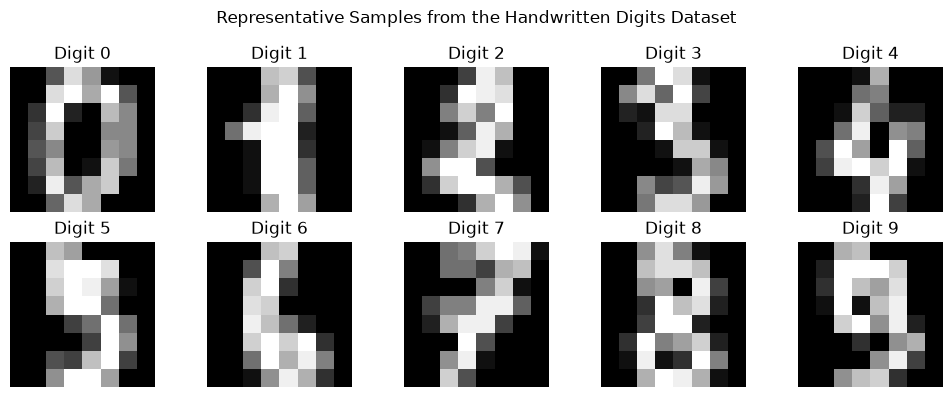

In [7]:
plt.figure(figsize=(10, 4))

for digit in range(10):
    sample_index = np.where(y == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(images[sample_index], cmap="gray")
    plt.title(f"Digit {digit}")
    plt.axis("off")

plt.suptitle("Representative Samples from the Handwritten Digits Dataset")
plt.tight_layout()
plt.show()

## 3] train validation test split

In [8]:
# First reserve 20% for final testing.
X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# From the remaining 80%, reserve 25% for validation.
# This gives approximately 60% train, 20% validation, and 20% test.
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=0.25,
    random_state=42,
    stratify=y_train_validation
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_validation.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1077
Validation samples: 360
Testing samples: 360


## 4] feature standardization

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Mean of standardized training features:", np.mean(X_train_scaled))
print("Standard deviation of standardized training features:", np.std(X_train_scaled))

Mean of standardized training features: -2.6802041448703873e-18
Standard deviation of standardized training features: 0.9682458365518524


## 5] multi-layer perceptrin architecture

In [20]:
def theoretical_parameter_count(input_units, hidden_layers, output_units):
    layer_sizes = [input_units] + list(hidden_layers) + [output_units]

    rows = []
    total_parameters = 0

    for layer_number in range(len(layer_sizes) - 1):
        n_in = layer_sizes[layer_number]
        n_out = layer_sizes[layer_number + 1]

        weight_count = n_in * n_out
        bias_count = n_out
        layer_parameters = weight_count + bias_count
        total_parameters += layer_parameters

        rows.append({
            "Connection": f"Layer {layer_number} → Layer {layer_number + 1}",
            "Input units": n_in,
            "Output units": n_out,
            "Weights": weight_count,
            "Biases": bias_count,
            "Layer parameters": layer_parameters
        })

    return pd.DataFrame(rows), total_parameters

## 6] experimental design

In [21]:
activation_functions = ["relu", "tanh", "logistic"]

layer_configurations = {
    "Small-Shallow": (32,),
    "Medium-Two-Layer": (64, 32),
    "Deep-Three-Layer": (128, 64, 32)
}

In [22]:
experiment_plan = []

for activation in activation_functions:
    for configuration_name, hidden_layers in layer_configurations.items():
        _, parameter_count = theoretical_parameter_count(
            input_units=X_train_scaled.shape[1],
            hidden_layers=hidden_layers,
            output_units=10
        )

In [23]:
experiment_plan.append({
            "Activation": activation,
            "Configuration": configuration_name,
            "Hidden layers": hidden_layers,
            "Trainable parameters": parameter_count
        })

experiment_plan = pd.DataFrame(experiment_plan)
display(experiment_plan)

,Activation,Configuration,Hidden layers,Trainable parameters
0,logistic,Deep-Three-Layer,"(128, 64, 32)",18986


## 7] training

In [26]:
def actual_parameter_count(model):
    weight_parameters = sum(matrix.size for matrix in model.coefs_)
    bias_parameters = sum(vector.size for vector in model.intercepts_)
    return weight_parameters + bias_parameters


def train_and_evaluate_mlp(
    activation,
    hidden_layers,
    configuration_name,
    X_train_data,
    y_train_data,
    X_validation_data,
    y_validation_data
):
  model = MLPClassifier(
          hidden_layer_sizes=hidden_layers,
          activation=activation,
          solver="adam",
          learning_rate_init=0.001,
          batch_size=64,
          max_iter=300,
          early_stopping=True,
          validation_fraction=0.15,
          n_iter_no_change=20,
          random_state=42
      )
  start_time = time.perf_counter()
  model.fit(X_train_data, y_train_data)
  elapsed_time = time.perf_counter() - start_time

  train_prediction = model.predict(X_train_data)
  validation_prediction = model.predict(X_validation_data)
  validation_probability = model.predict_proba(X_validation_data)

  result = {
        "Activation": activation,
        "Configuration": configuration_name,
        "Hidden layers": hidden_layers,
        "Parameters": actual_parameter_count(model),
        "Iterations": model.n_iter_,
        "Training time (s)": elapsed_time,
        "Final training loss": model.loss_,
        "Training accuracy": accuracy_score(y_train_data, train_prediction),
        "Validation accuracy": accuracy_score(
            y_validation_data,
            validation_prediction
        ),
        "Validation macro F1": f1_score(
            y_validation_data,
            validation_prediction,
            average="macro"
        ),
        "Validation log loss": log_loss(
            y_validation_data,
            validation_probability
        )
    }

  return model, result

## 8] run all experiments

In [27]:
trained_models = {}
experiment_results = []

for activation in activation_functions:
    for configuration_name, hidden_layers in layer_configurations.items():

        model, result = train_and_evaluate_mlp(
            activation=activation,
            hidden_layers=hidden_layers,
            configuration_name=configuration_name,
            X_train_data=X_train_scaled,
            y_train_data=y_train,
            X_validation_data=X_validation_scaled,
            y_validation_data=y_validation
        )
        model_key = f"{activation} | {configuration_name}"
        trained_models[model_key] = model
        experiment_results.append(result)

        print(
            f"Completed: {model_key} | "
            f"Validation accuracy = {result['Validation accuracy']:.4f}"
        )

results_df = pd.DataFrame(experiment_results)
print("\nAll experiments completed.")

Completed: relu | Small-Shallow | Validation accuracy = 0.9500
Completed: relu | Medium-Two-Layer | Validation accuracy = 0.9361
Completed: relu | Deep-Three-Layer | Validation accuracy = 0.9722
Completed: tanh | Small-Shallow | Validation accuracy = 0.9444
Completed: tanh | Medium-Two-Layer | Validation accuracy = 0.9472
Completed: tanh | Deep-Three-Layer | Validation accuracy = 0.9639
Completed: logistic | Small-Shallow | Validation accuracy = 0.9556
Completed: logistic | Medium-Two-Layer | Validation accuracy = 0.9500
Completed: logistic | Deep-Three-Layer | Validation accuracy = 0.9417

All experiments completed.


## 9] experimental results

In [28]:
ranked_results = results_df.sort_values(
    by=["Validation accuracy", "Validation macro F1"],
    ascending=[False, False]
).reset_index(drop=True)

ranked_results.index = ranked_results.index + 1
ranked_results.index.name = "Rank"

display(ranked_results)

,Activation,Configuration,Hidden layers,Parameters,Iterations,Training time (s),Final training loss,Training accuracy,Validation accuracy,Validation macro F1,Validation log loss
Rank,,,,,,,,,,,
1,relu,Deep-Three-Layer,"(128, 64, 32)",18986,36,0.6470,0.0026,0.9954,0.9722,0.9721,0.1073
2,tanh,Deep-Three-Layer,"(128, 64, 32)",18986,30,0.6319,0.0224,0.9851,0.9639,0.9635,0.2254
3,logistic,Small-Shallow,"(32,)",2410,86,0.6080,0.1094,0.9805,0.9556,0.9556,0.2374
4,relu,Small-Shallow,"(32,)",2410,62,0.4104,0.0305,0.9935,0.9500,0.9497,0.1538
5,logistic,Medium-Two-Layer,"(64, 32)",6570,83,1.0830,0.0854,0.9796,0.9500,0.9495,0.2308
6,tanh,Medium-Two-Layer,"(64, 32)",6570,40,0.3876,0.0339,0.9870,0.9472,0.9470,0.2268
7,tanh,Small-Shallow,"(32,)",2410,53,0.2978,0.0622,0.9805,0.9444,0.9446,0.2286
8,logistic,Deep-Three-Layer,"(128, 64, 32)",18986,93,2.6000,0.0499,0.9889,0.9417,0.9416,0.2279
9,relu,Medium-Two-Layer,"(64, 32)",6570,38,0.3448,0.0118,0.9898,0.9361,0.9363,0.2172


***